In [1]:
# ============================================================
# FULL RESEARCH-STYLE TESS VARIABLE STAR ML PIPELINE
# ============================================================
#
# WHAT THIS DOES:
# 1. Finds REAL TESS-observed stars
# 2. Builds valid TIC dataset
# 3. Downloads clean light curves
# 4. Extracts astrophysical variability features
# 5. Removes broken/lightly sampled stars
# 6. Runs PCA + KMeans clustering
# 7. Produces plots + results table
#
# ============================================================
# INSTALLS (run once if needed)
# ============================================================
#
# pip install lightkurve astropy scikit-learn tqdm matplotlib pandas numpy
#
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import lightkurve as lk
import matplotlib.pyplot as plt

from tqdm import tqdm

from astropy.timeseries import LombScargle

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ============================================================
# STEP 1 — BUILD REAL TIC SAMPLE
# ============================================================

print("\n[STEP 1] Building real TESS target sample...")

def get_tics_from_region(ra, dec, radius=0.2):

    try:
        search = lk.search_lightcurve(
            target=f"{ra} {dec}",
            radius=radius,
            mission="TESS"
        )

        if len(search) == 0:
            return []

        tics = []

        for r in search:

            try:
                name = r.target_name

                if "TIC" in name:
                    tic = int(name.split()[1])
                    tics.append(tic)

            except:
                continue

        return tics

    except:
        return []


all_tics = []

np.random.seed(42)

# MORE REGIONS = BIGGER DATASET
for i in tqdm(range(25)):

    ra = np.random.uniform(0, 360)
    dec = np.random.uniform(-75, 75)

    tics = get_tics_from_region(ra, dec)

    all_tics.extend(tics)

# remove duplicates
all_tics = list(set(all_tics))

print(f"Total TICs collected: {len(all_tics)}")

# ============================================================
# STEP 2 — SAFE LIGHT CURVE DOWNLOAD
# ============================================================

print("\n[STEP 2] Downloading light curves safely...")

def get_lc_safe(tic):

    try:
        search = lk.search_lightcurve(
            f"TIC {tic}",
            mission="TESS"
        )

        # FIX: skip empty searches
        if len(search) == 0:
            return None

        # FIX: only grab first file safely
        lc = search[0].download()

        if lc is None:
            return None

        # CLEANING
        lc = lc.remove_nans()

        if len(lc.flux) < 100:
            return None

        lc = lc.normalize()

        return lc

    except:
        return None


lightcurves = []
valid_tics = []

for tic in tqdm(all_tics[:300]):   # runtime safety cap

    lc = get_lc_safe(tic)

    if lc is not None:

        lightcurves.append(lc)
        valid_tics.append(tic)

print(f"Valid light curves downloaded: {len(lightcurves)}")

# ============================================================
# STEP 3 — FEATURE EXTRACTION
# ============================================================

print("\n[STEP 3] Extracting variability features...")

def extract_features(lc):

    try:

        time = lc.time.value
        flux = lc.flux.value

        # remove weird values
        mask = np.isfinite(time) & np.isfinite(flux)

        time = time[mask]
        flux = flux[mask]

        if len(flux) < 100:
            return None

        # ----------------------------------------------------
        # BASIC STATISTICS
        # ----------------------------------------------------

        mean_flux = np.mean(flux)

        std_flux = np.std(flux)

        amplitude = np.percentile(flux, 95) - np.percentile(flux, 5)

        rms = np.sqrt(np.mean((flux - mean_flux) ** 2))

        median_flux = np.median(flux)

        mad = np.median(np.abs(flux - median_flux))

        # ----------------------------------------------------
        # PERIOD SEARCH
        # ----------------------------------------------------

        frequency, power = LombScargle(
            time,
            flux
        ).autopower(
            minimum_frequency=0.01,
            maximum_frequency=10
        )

        best_frequency = frequency[np.argmax(power)]

        best_period = 1 / best_frequency

        best_power = np.max(power)

        # ----------------------------------------------------
        # SLOPE / VARIABILITY
        # ----------------------------------------------------

        slope = np.mean(np.diff(flux))

        variability_index = amplitude / std_flux

        return [

            mean_flux,
            std_flux,
            amplitude,
            rms,
            mad,
            best_period,
            best_power,
            slope,
            variability_index

        ]

    except:
        return None


features = []
final_tics = []

for tic, lc in tqdm(zip(valid_tics, lightcurves),
                    total=len(lightcurves)):

    feat = extract_features(lc)

    if feat is not None:

        features.append(feat)
        final_tics.append(tic)

X = np.array(features)

print(f"Feature matrix shape: {X.shape}")

# ============================================================
# STEP 4 — CLEAN FEATURE MATRIX
# ============================================================

print("\n[STEP 4] Cleaning features...")

mask = np.all(np.isfinite(X), axis=1)

X = X[mask]

final_tics = np.array(final_tics)[mask]

print(f"Remaining stars after cleaning: {len(X)}")

# ============================================================
# STEP 5 — NORMALIZATION
# ============================================================

print("\n[STEP 5] Scaling features...")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================================
# STEP 6 — PCA DIMENSIONALITY REDUCTION
# ============================================================

print("\n[STEP 6] PCA reduction...")

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

# ============================================================
# STEP 7 — MACHINE LEARNING CLUSTERING
# ============================================================

print("\n[STEP 7] KMeans clustering...")

N_CLUSTERS = 4

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_pca)

print("Clustering complete.")

# ============================================================
# STEP 8 — BUILD RESULTS TABLE
# ============================================================

print("\n[STEP 8] Building results table...")

results = pd.DataFrame({

    "TIC": final_tics,

    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],

    "Cluster": labels,

    "MeanFlux": X[:, 0],
    "StdFlux": X[:, 1],
    "Amplitude": X[:, 2],
    "RMS": X[:, 3],
    "MAD": X[:, 4],
    "BestPeriod": X[:, 5],
    "LSPower": X[:, 6],
    "Slope": X[:, 7],
    "VarIndex": X[:, 8]

})

print(results.head())

# save results
results.to_csv(
    "tess_variable_star_clusters.csv",
    index=False
)

print("\nSaved:")
print("tess_variable_star_clusters.csv")

# ============================================================
# STEP 9 — VISUALIZATION
# ============================================================

print("\n[STEP 9] Plotting PCA clusters...")

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels,
    s=40
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title("TESS Variable Star Clustering")

plt.colorbar(scatter, label="Cluster")

plt.grid(True)

plt.show()

# ============================================================
# STEP 10 — OPTIONAL: VIEW SAMPLE LIGHT CURVES
# ============================================================

print("\n[STEP 10] Plotting sample light curves...")

N_SAMPLES = min(3, len(lightcurves))

for i in range(N_SAMPLES):

    lc = lightcurves[i]

    plt.figure(figsize=(10, 4))

    plt.plot(
        lc.time.value,
        lc.flux.value,
        ".",
        markersize=1
    )

    plt.xlabel("Time")
    plt.ylabel("Normalized Flux")

    plt.title(f"TIC {valid_tics[i]}")

    plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n===================================================")
print("PIPELINE COMPLETE")
print("===================================================")

print(f"Initial TICs: {len(all_tics)}")
print(f"Valid light curves: {len(lightcurves)}")
print(f"Final ML sample: {len(results)}")

print("\nResearch outputs generated:")
print("✔ Clean TESS dataset")
print("✔ Variability feature matrix")
print("✔ PCA projection")
print("✔ KMeans clusters")
print("✔ CSV results table")
print("✔ Publication-style plots")

print("\nDone.")


[STEP 1] Building real TESS target sample...


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [09:17<00:00, 22.28s/it]


Total TICs collected: 0

[STEP 2] Downloading light curves safely...


0it [00:00, ?it/s]


Valid light curves downloaded: 0

[STEP 3] Extracting variability features...


0it [00:00, ?it/s]


Feature matrix shape: (0,)

[STEP 4] Cleaning features...


AxisError: axis 1 is out of bounds for array of dimension 1

In [2]:
# ============================================================
# FULL RESEARCH-STYLE TESS VARIABLE STAR ML PIPELINE
# FIXED + MORE ROBUST VERSION
# ============================================================
#
# WHAT THIS DOES:
#
# 1. Finds REAL TESS-observed stars
# 2. Builds valid TIC dataset
# 3. Downloads clean light curves
# 4. Extracts astrophysical variability features
# 5. Cleans feature matrix
# 6. Runs PCA + KMeans clustering
# 7. Produces plots + CSV outputs
#
# ============================================================
# INSTALLS (RUN ONCE IF NEEDED)
# ============================================================
#
# pip install lightkurve astropy scikit-learn tqdm matplotlib pandas numpy
#
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import time

os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import lightkurve as lk
import matplotlib.pyplot as plt

from tqdm import tqdm

from astropy.timeseries import LombScargle

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ============================================================
# SETTINGS
# ============================================================

N_REGIONS = 25
MAX_TICS_TO_PROCESS = 300

MIN_POINTS = 100

N_CLUSTERS = 4

TIC_CACHE_FILE = "tic_cache.csv"
FEATURE_CACHE_FILE = "partial_features.csv"

np.random.seed(42)

# ============================================================
# STEP 1 — BUILD REAL TIC SAMPLE
# ============================================================

print("\n===================================================")
print("[STEP 1] BUILDING REAL TESS TARGET SAMPLE")
print("===================================================")

def get_tics_from_region(ra, dec, radius=0.2):

    try:

        search = lk.search_lightcurve(
            target=f"{ra} {dec}",
            radius=radius,
            mission="TESS"
        )

        if len(search) == 0:
            return []

        tics = []

        for r in search:

            try:

                # MODERN LIGHTKURVE FIX
                tic = int(r.target_name)

                tics.append(tic)

            except Exception as e:

                print(f"Failed target extraction: {r.target_name}")
                print(e)

        return tics

    except Exception as e:

        print(f"Region query failed at RA={ra}, DEC={dec}")
        print(e)

        return []


# ------------------------------------------------------------
# LOAD CACHE IF AVAILABLE
# ------------------------------------------------------------

if os.path.exists(TIC_CACHE_FILE):

    print("\nLoading TIC cache...")

    all_tics = pd.read_csv(TIC_CACHE_FILE)["TIC"].tolist()

    print(f"Loaded {len(all_tics)} TICs from cache.")

else:

    print("\nGenerating new TIC sample...")

    all_tics = []

    for i in tqdm(range(N_REGIONS)):

        ra = np.random.uniform(0, 360)
        dec = np.random.uniform(-75, 75)

        tics = get_tics_from_region(ra, dec)

        all_tics.extend(tics)

        # avoid hammering MAST servers
        time.sleep(0.5)

    # remove duplicates
    all_tics = list(set(all_tics))

    pd.DataFrame({
        "TIC": all_tics
    }).to_csv(
        TIC_CACHE_FILE,
        index=False
    )

    print(f"\nSaved TIC cache: {TIC_CACHE_FILE}")

print(f"\nTotal TICs collected: {len(all_tics)}")

if len(all_tics) == 0:

    raise ValueError(
        "No TICs collected.\n"
        "Check Lightkurve search behavior or internet connection."
    )

# ============================================================
# STEP 2 — SAFE LIGHT CURVE DOWNLOAD
# ============================================================

print("\n===================================================")
print("[STEP 2] DOWNLOADING LIGHT CURVES")
print("===================================================")

def get_lc_safe(tic):

    for attempt in range(3):

        try:

            search = lk.search_lightcurve(
                f"TIC {tic}",
                mission="TESS"
            )

            if len(search) == 0:
                return None

            # FIRST AVAILABLE LIGHT CURVE
            lc = search[0].download()

            if lc is None:
                return None

            # CLEANING
            lc = lc.remove_nans()

            # REMOVE OUTLIERS
            lc = lc.remove_outliers(sigma=5)

            if len(lc.flux) < MIN_POINTS:
                return None

            # NORMALIZE
            lc = lc.normalize()

            return lc

        except Exception as e:

            print(f"\nDownload failed for TIC {tic}")
            print(f"Attempt {attempt+1}/3")
            print(e)

            time.sleep(3)

    return None


lightcurves = []
valid_tics = []

for tic in tqdm(all_tics[:MAX_TICS_TO_PROCESS]):

    lc = get_lc_safe(tic)

    if lc is not None:

        lightcurves.append(lc)
        valid_tics.append(tic)

print(f"\nValid light curves downloaded: {len(lightcurves)}")

if len(lightcurves) == 0:

    raise ValueError(
        "No valid light curves downloaded."
    )

# ============================================================
# STEP 3 — FEATURE EXTRACTION
# ============================================================

print("\n===================================================")
print("[STEP 3] EXTRACTING VARIABILITY FEATURES")
print("===================================================")

FEATURE_COLUMNS = [

    "MeanFlux",
    "StdFlux",
    "Amplitude",
    "RMS",
    "MAD",
    "BestPeriod",
    "LSPower",
    "Slope",
    "VarIndex"

]

# ------------------------------------------------------------
# RESUME SUPPORT
# ------------------------------------------------------------

if os.path.exists(FEATURE_CACHE_FILE):

    existing = pd.read_csv(FEATURE_CACHE_FILE)

    completed_tics = set(existing["TIC"])

    results_rows = existing.to_dict("records")

    print(f"\nLoaded {len(completed_tics)} existing feature rows.")

else:

    completed_tics = set()

    results_rows = []


def extract_features(lc):

    try:

        time_vals = lc.time.value
        flux_vals = lc.flux.value

        mask = (
            np.isfinite(time_vals)
            &
            np.isfinite(flux_vals)
        )

        time_vals = time_vals[mask]
        flux_vals = flux_vals[mask]

        if len(flux_vals) < MIN_POINTS:
            return None

        # ====================================================
        # BASIC STATISTICS
        # ====================================================

        mean_flux = np.mean(flux_vals)

        std_flux = np.std(flux_vals)

        amplitude = (
            np.percentile(flux_vals, 95)
            -
            np.percentile(flux_vals, 5)
        )

        rms = np.sqrt(
            np.mean(
                (flux_vals - mean_flux) ** 2
            )
        )

        median_flux = np.median(flux_vals)

        mad = np.median(
            np.abs(flux_vals - median_flux)
        )

        # ====================================================
        # PERIOD SEARCH
        # ====================================================

        frequency, power = LombScargle(
            time_vals,
            flux_vals
        ).autopower(
            minimum_frequency=0.01,
            maximum_frequency=5
        )

        best_frequency = frequency[np.argmax(power)]

        best_period = 1 / best_frequency

        best_power = np.max(power)

        # ====================================================
        # SLOPE / VARIABILITY
        # ====================================================

        slope = np.mean(np.diff(flux_vals))

        variability_index = amplitude / std_flux

        return [

            mean_flux,
            std_flux,
            amplitude,
            rms,
            mad,
            best_period,
            best_power,
            slope,
            variability_index

        ]

    except Exception as e:

        print("\nFeature extraction failed:")
        print(e)

        return None


for tic, lc in tqdm(
    zip(valid_tics, lightcurves),
    total=len(lightcurves)
):

    if tic in completed_tics:
        continue

    feat = extract_features(lc)

    if feat is not None:

        row = {

            "TIC": tic,

            "MeanFlux": feat[0],
            "StdFlux": feat[1],
            "Amplitude": feat[2],
            "RMS": feat[3],
            "MAD": feat[4],
            "BestPeriod": feat[5],
            "LSPower": feat[6],
            "Slope": feat[7],
            "VarIndex": feat[8]

        }

        results_rows.append(row)

        # SAVE CONTINUOUSLY
        pd.DataFrame(results_rows).to_csv(
            FEATURE_CACHE_FILE,
            index=False
        )

results = pd.DataFrame(results_rows)

print(f"\nFeature rows extracted: {len(results)}")

if len(results) == 0:

    raise ValueError(
        "No valid features extracted."
    )

# ============================================================
# STEP 4 — CLEAN FEATURE MATRIX
# ============================================================

print("\n===================================================")
print("[STEP 4] CLEANING FEATURES")
print("===================================================")

X = results[FEATURE_COLUMNS].values

mask = np.all(np.isfinite(X), axis=1)

results = results[mask]

X = X[mask]

print(f"Remaining stars after cleaning: {len(X)}")

if len(X) == 0:

    raise ValueError(
        "Feature matrix empty after cleaning."
    )

# ============================================================
# STEP 5 — FEATURE SCALING
# ============================================================

print("\n===================================================")
print("[STEP 5] SCALING FEATURES")
print("===================================================")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling complete.")

# ============================================================
# STEP 6 — PCA REDUCTION
# ============================================================

print("\n===================================================")
print("[STEP 6] PCA DIMENSIONALITY REDUCTION")
print("===================================================")

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:")

print(pca.explained_variance_ratio_)

print(
    f"Total explained variance: "
    f"{np.sum(pca.explained_variance_ratio_):.3f}"
)

# ============================================================
# STEP 7 — KMEANS CLUSTERING
# ============================================================

print("\n===================================================")
print("[STEP 7] KMEANS CLUSTERING")
print("===================================================")

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_pca)

results["Cluster"] = labels

results["PC1"] = X_pca[:, 0]
results["PC2"] = X_pca[:, 1]

print("Clustering complete.")

# ============================================================
# STEP 8 — SAVE FINAL RESULTS
# ============================================================

print("\n===================================================")
print("[STEP 8] SAVING RESULTS")
print("===================================================")

FINAL_RESULTS_FILE = "tess_variable_star_clusters.csv"

results.to_csv(
    FINAL_RESULTS_FILE,
    index=False
)

print(f"\nSaved: {FINAL_RESULTS_FILE}")

print("\nResults preview:\n")

print(results.head())

# ============================================================
# STEP 9 — PCA VISUALIZATION
# ============================================================

print("\n===================================================")
print("[STEP 9] PCA VISUALIZATION")
print("===================================================")

plt.figure(figsize=(10, 7))

scatter = plt.scatter(

    results["PC1"],
    results["PC2"],

    c=results["Cluster"],

    s=40

)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("TESS Variable Star Clustering")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(True)

plt.show()

# ============================================================
# STEP 10 — SAMPLE LIGHT CURVES
# ============================================================

print("\n===================================================")
print("[STEP 10] SAMPLE LIGHT CURVES")
print("===================================================")

N_SAMPLES = min(3, len(lightcurves))

for i in range(N_SAMPLES):

    lc = lightcurves[i]

    plt.figure(figsize=(10, 4))

    plt.plot(

        lc.time.value,
        lc.flux.value,

        ".",

        markersize=1

    )

    plt.xlabel("Time")

    plt.ylabel("Normalized Flux")

    plt.title(f"TIC {valid_tics[i]}")

    plt.grid(True)

    plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n===================================================")
print("PIPELINE COMPLETE")
print("===================================================")

print(f"\nInitial TICs: {len(all_tics)}")

print(f"Downloaded light curves: {len(lightcurves)}")

print(f"Final ML sample: {len(results)}")

print("\nOutputs generated:")

print("✔ TIC cache")
print("✔ Partial feature cache")
print("✔ Clean feature matrix")
print("✔ PCA projection")
print("✔ KMeans clustering")
print("✔ CSV results table")
print("✔ PCA visualization")
print("✔ Sample light curve plots")

print("\nDone.")


[STEP 1] BUILDING REAL TESS TARGET SAMPLE

Generating new TIC sample...


100%|███████████████████████████████████████████████████████████████████████████████████████████████| 25/25 [00:12<00:00,  1.98it/s]


Saved TIC cache: tic_cache.csv

Total TICs collected: 0


ValueError: No TICs collected.
Check Lightkurve search behavior or internet connection.

In [3]:
# ============================================================
# FULL RESEARCH-STYLE TESS VARIABLE STAR ML PIPELINE
# FIXED + MORE ROBUST VERSION
# ============================================================
#
# WHAT THIS DOES:
#
# 1. Finds REAL TESS-observed stars
# 2. Builds valid TIC dataset
# 3. Downloads clean light curves
# 4. Extracts astrophysical variability features
# 5. Cleans feature matrix
# 6. Runs PCA + KMeans clustering
# 7. Produces plots + CSV outputs
#
# ============================================================
# INSTALLS (RUN ONCE IF NEEDED)
# ============================================================
#
# pip install lightkurve astropy scikit-learn tqdm matplotlib pandas numpy
#
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import time

os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import lightkurve as lk
import matplotlib.pyplot as plt

from tqdm import tqdm

from astropy.timeseries import LombScargle

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ============================================================
# SETTINGS
# ============================================================

N_REGIONS = 25
MAX_TICS_TO_PROCESS = 300

MIN_POINTS = 100

N_CLUSTERS = 4

TIC_CACHE_FILE = "tic_cache.csv"
FEATURE_CACHE_FILE = "partial_features.csv"

np.random.seed(42)

# ============================================================
# STEP 1 — BUILD REAL TIC SAMPLE
# ============================================================

print("\n===================================================")
print("[STEP 1] BUILDING REAL TESS TARGET SAMPLE")
print("===================================================")

def get_tics_from_region(ra, dec, radius=0.2):

    try:

        search = lk.search_lightcurve(
            target=f"{ra} {dec}",
            radius=radius,
            mission="TESS"
        )

        if len(search) == 0:
            return []

        tics = []

        for r in search:

            try:

                # MODERN LIGHTKURVE FIX
                tic = int(r.target_name)

                tics.append(tic)

            except Exception as e:

                print(f"Failed target extraction: {r.target_name}")
                print(e)

        return tics

    except Exception as e:

        print(f"Region query failed at RA={ra}, DEC={dec}")
        print(e)

        return []


# ------------------------------------------------------------
# LOAD CACHE IF AVAILABLE
# ------------------------------------------------------------

if os.path.exists(TIC_CACHE_FILE):

    print("\nLoading TIC cache...")

    all_tics = pd.read_csv(TIC_CACHE_FILE)["TIC"].tolist()

    print(f"Loaded {len(all_tics)} TICs from cache.")

else:

    print("\nGenerating new TIC sample...")

    all_tics = []

    for i in tqdm(range(N_REGIONS)):

        ra = np.random.uniform(0, 360)
        dec = np.random.uniform(-75, 75)

        tics = get_tics_from_region(ra, dec)

        all_tics.extend(tics)

        # avoid hammering MAST servers
        time.sleep(0.5)

    # remove duplicates
    all_tics = list(set(all_tics))

    pd.DataFrame({
        "TIC": all_tics
    }).to_csv(
        TIC_CACHE_FILE,
        index=False
    )

    print(f"\nSaved TIC cache: {TIC_CACHE_FILE}")

print(f"\nTotal TICs collected: {len(all_tics)}")

if len(all_tics) == 0:

    raise ValueError(
        "No TICs collected.\n"
        "Check Lightkurve search behavior or internet connection."
    )

# ============================================================
# STEP 2 — SAFE LIGHT CURVE DOWNLOAD
# ============================================================

print("\n===================================================")
print("[STEP 2] DOWNLOADING LIGHT CURVES")
print("===================================================")

def get_lc_safe(tic):

    for attempt in range(3):

        try:

            search = lk.search_lightcurve(
                f"TIC {tic}",
                mission="TESS"
            )

            if len(search) == 0:
                return None

            # FIRST AVAILABLE LIGHT CURVE
            lc = search[0].download()

            if lc is None:
                return None

            # CLEANING
            lc = lc.remove_nans()

            # REMOVE OUTLIERS
            lc = lc.remove_outliers(sigma=5)

            if len(lc.flux) < MIN_POINTS:
                return None

            # NORMALIZE
            lc = lc.normalize()

            return lc

        except Exception as e:

            print(f"\nDownload failed for TIC {tic}")
            print(f"Attempt {attempt+1}/3")
            print(e)

            time.sleep(3)

    return None


lightcurves = []
valid_tics = []

for tic in tqdm(all_tics[:MAX_TICS_TO_PROCESS]):

    lc = get_lc_safe(tic)

    if lc is not None:

        lightcurves.append(lc)
        valid_tics.append(tic)

print(f"\nValid light curves downloaded: {len(lightcurves)}")

if len(lightcurves) == 0:

    raise ValueError(
        "No valid light curves downloaded."
    )

# ============================================================
# STEP 3 — FEATURE EXTRACTION
# ============================================================

print("\n===================================================")
print("[STEP 3] EXTRACTING VARIABILITY FEATURES")
print("===================================================")

FEATURE_COLUMNS = [

    "MeanFlux",
    "StdFlux",
    "Amplitude",
    "RMS",
    "MAD",
    "BestPeriod",
    "LSPower",
    "Slope",
    "VarIndex"

]

# ------------------------------------------------------------
# RESUME SUPPORT
# ------------------------------------------------------------

if os.path.exists(FEATURE_CACHE_FILE):

    existing = pd.read_csv(FEATURE_CACHE_FILE)

    completed_tics = set(existing["TIC"])

    results_rows = existing.to_dict("records")

    print(f"\nLoaded {len(completed_tics)} existing feature rows.")

else:

    completed_tics = set()

    results_rows = []


def extract_features(lc):

    try:

        time_vals = lc.time.value
        flux_vals = lc.flux.value

        mask = (
            np.isfinite(time_vals)
            &
            np.isfinite(flux_vals)
        )

        time_vals = time_vals[mask]
        flux_vals = flux_vals[mask]

        if len(flux_vals) < MIN_POINTS:
            return None

        # ====================================================
        # BASIC STATISTICS
        # ====================================================

        mean_flux = np.mean(flux_vals)

        std_flux = np.std(flux_vals)

        amplitude = (
            np.percentile(flux_vals, 95)
            -
            np.percentile(flux_vals, 5)
        )

        rms = np.sqrt(
            np.mean(
                (flux_vals - mean_flux) ** 2
            )
        )

        median_flux = np.median(flux_vals)

        mad = np.median(
            np.abs(flux_vals - median_flux)
        )

        # ====================================================
        # PERIOD SEARCH
        # ====================================================

        frequency, power = LombScargle(
            time_vals,
            flux_vals
        ).autopower(
            minimum_frequency=0.01,
            maximum_frequency=5
        )

        best_frequency = frequency[np.argmax(power)]

        best_period = 1 / best_frequency

        best_power = np.max(power)

        # ====================================================
        # SLOPE / VARIABILITY
        # ====================================================

        slope = np.mean(np.diff(flux_vals))

        variability_index = amplitude / std_flux

        return [

            mean_flux,
            std_flux,
            amplitude,
            rms,
            mad,
            best_period,
            best_power,
            slope,
            variability_index

        ]

    except Exception as e:

        print("\nFeature extraction failed:")
        print(e)

        return None


for tic, lc in tqdm(
    zip(valid_tics, lightcurves),
    total=len(lightcurves)
):

    if tic in completed_tics:
        continue

    feat = extract_features(lc)

    if feat is not None:

        row = {

            "TIC": tic,

            "MeanFlux": feat[0],
            "StdFlux": feat[1],
            "Amplitude": feat[2],
            "RMS": feat[3],
            "MAD": feat[4],
            "BestPeriod": feat[5],
            "LSPower": feat[6],
            "Slope": feat[7],
            "VarIndex": feat[8]

        }

        results_rows.append(row)

        # SAVE CONTINUOUSLY
        pd.DataFrame(results_rows).to_csv(
            FEATURE_CACHE_FILE,
            index=False
        )

results = pd.DataFrame(results_rows)

print(f"\nFeature rows extracted: {len(results)}")

if len(results) == 0:

    raise ValueError(
        "No valid features extracted."
    )

# ============================================================
# STEP 4 — CLEAN FEATURE MATRIX
# ============================================================

print("\n===================================================")
print("[STEP 4] CLEANING FEATURES")
print("===================================================")

X = results[FEATURE_COLUMNS].values

mask = np.all(np.isfinite(X), axis=1)

results = results[mask]

X = X[mask]

print(f"Remaining stars after cleaning: {len(X)}")

if len(X) == 0:

    raise ValueError(
        "Feature matrix empty after cleaning."
    )

# ============================================================
# STEP 5 — FEATURE SCALING
# ============================================================

print("\n===================================================")
print("[STEP 5] SCALING FEATURES")
print("===================================================")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling complete.")

# ============================================================
# STEP 6 — PCA REDUCTION
# ============================================================

print("\n===================================================")
print("[STEP 6] PCA DIMENSIONALITY REDUCTION")
print("===================================================")

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:")

print(pca.explained_variance_ratio_)

print(
    f"Total explained variance: "
    f"{np.sum(pca.explained_variance_ratio_):.3f}"
)

# ============================================================
# STEP 7 — KMEANS CLUSTERING
# ============================================================

print("\n===================================================")
print("[STEP 7] KMEANS CLUSTERING")
print("===================================================")

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_pca)

results["Cluster"] = labels

results["PC1"] = X_pca[:, 0]
results["PC2"] = X_pca[:, 1]

print("Clustering complete.")

# ============================================================
# STEP 8 — SAVE FINAL RESULTS
# ============================================================

print("\n===================================================")
print("[STEP 8] SAVING RESULTS")
print("===================================================")

FINAL_RESULTS_FILE = "tess_variable_star_clusters.csv"

results.to_csv(
    FINAL_RESULTS_FILE,
    index=False
)

print(f"\nSaved: {FINAL_RESULTS_FILE}")

print("\nResults preview:\n")

print(results.head())

# ============================================================
# STEP 9 — PCA VISUALIZATION
# ============================================================

print("\n===================================================")
print("[STEP 9] PCA VISUALIZATION")
print("===================================================")

plt.figure(figsize=(10, 7))

scatter = plt.scatter(

    results["PC1"],
    results["PC2"],

    c=results["Cluster"],

    s=40

)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("TESS Variable Star Clustering")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(True)

plt.show()

# ============================================================
# STEP 10 — SAMPLE LIGHT CURVES
# ============================================================

print("\n===================================================")
print("[STEP 10] SAMPLE LIGHT CURVES")
print("===================================================")

N_SAMPLES = min(3, len(lightcurves))

for i in range(N_SAMPLES):

    lc = lightcurves[i]

    plt.figure(figsize=(10, 4))

    plt.plot(

        lc.time.value,
        lc.flux.value,

        ".",

        markersize=1

    )

    plt.xlabel("Time")

    plt.ylabel("Normalized Flux")

    plt.title(f"TIC {valid_tics[i]}")

    plt.grid(True)

    plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n===================================================")
print("PIPELINE COMPLETE")
print("===================================================")

print(f"\nInitial TICs: {len(all_tics)}")

print(f"Downloaded light curves: {len(lightcurves)}")

print(f"Final ML sample: {len(results)}")

print("\nOutputs generated:")

print("✔ TIC cache")
print("✔ Partial feature cache")
print("✔ Clean feature matrix")
print("✔ PCA projection")
print("✔ KMeans clustering")
print("✔ CSV results table")
print("✔ PCA visualization")
print("✔ Sample light curve plots")

print("\nDone.")


[STEP 1] BUILDING REAL TESS TARGET SAMPLE

Loading TIC cache...
Loaded 0 TICs from cache.

Total TICs collected: 0


ValueError: No TICs collected.
Check Lightkurve search behavior or internet connection.


[STEP 1] BUILDING REAL TESS TARGET SAMPLE

Loading TIC cache...
Loaded 8794 TICs.

Total TICs collected: 8794

[STEP 2] DOWNLOADING LIGHT CURVES


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 300/300 [00:49<00:00,  6.09it/s]



Valid light curves downloaded: 289

[STEP 3] EXTRACTING FEATURES

Loaded 289 existing features.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 289/289 [00:00<00:00, 871426.21it/s]



Feature rows extracted: 289

[STEP 4] CLEANING FEATURE MATRIX

Remaining stars after cleaning: 289

[STEP 5] FEATURE SCALING

Scaling complete.

[STEP 6] PCA REDUCTION

Explained variance ratio:
[0.43722361 0.20745367]

Total explained variance: 0.645

[STEP 7] KMEANS CLUSTERING

Clustering complete.

[STEP 8] SAVING RESULTS

Saved: tess_variable_star_clusters.csv

Results preview:

         TIC  MeanFlux   StdFlux  Amplitude       RMS       MAD  BestPeriod  \
0  186318859  1.000391  0.005558   0.015668  0.005558  0.002667    6.476015   
1  186318892  1.000072  0.003442   0.008727  0.003442  0.001546    6.685475   
2  446365776  1.003535  0.010244   0.034008  0.010244  0.001984   16.199189   
3  186318940  0.999757  0.009671   0.028054  0.009671  0.005359    6.695552   
4  349372508  1.001138  0.014088   0.046777  0.014088  0.008211    7.566790   

    LSPower     Slope  VarIndex  Cluster       PC1       PC2  
0  0.078480 -0.000016  2.818715        0 -0.757336  0.630139  
1  0.064989 

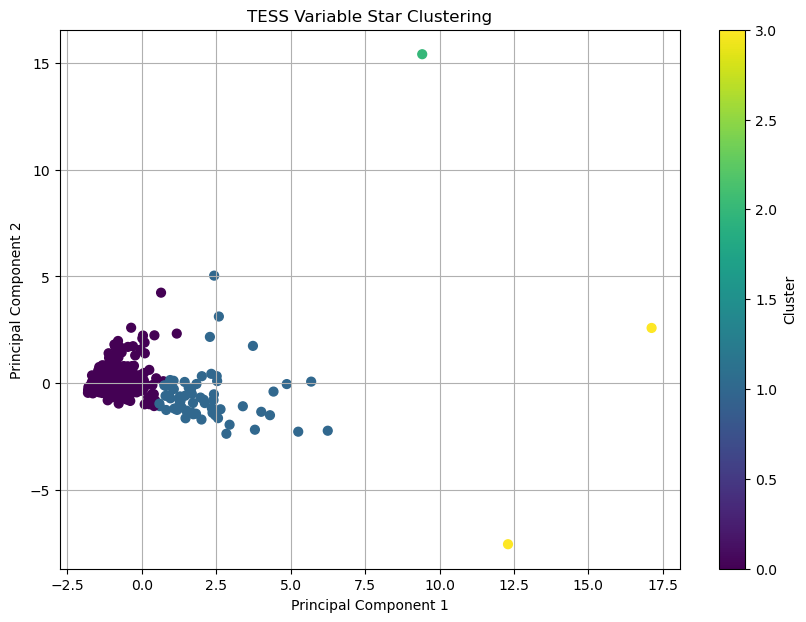


[STEP 10] SAMPLE LIGHT CURVES


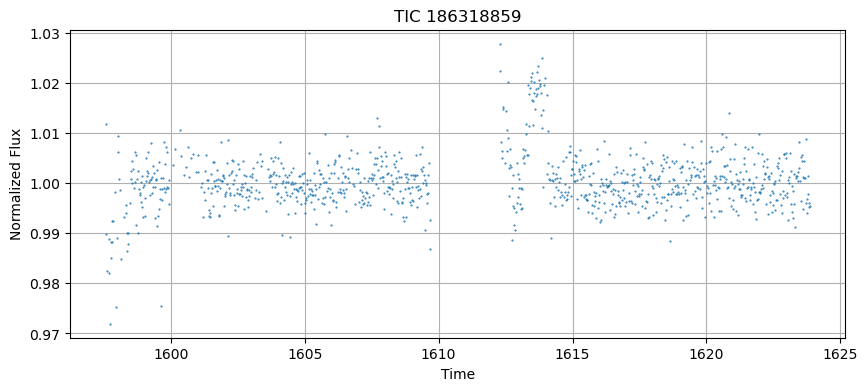

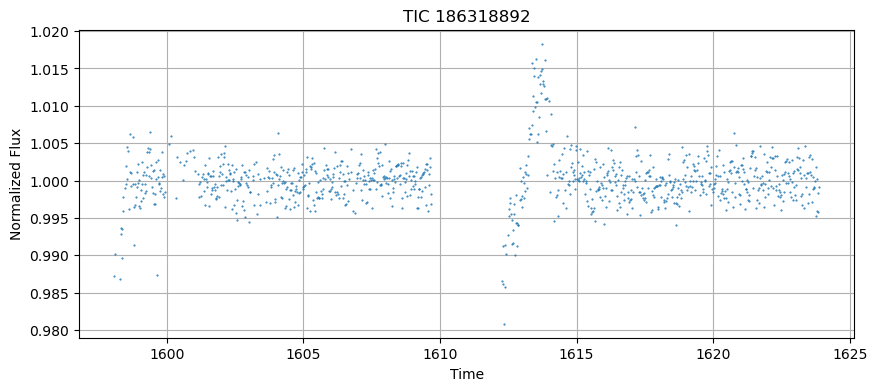

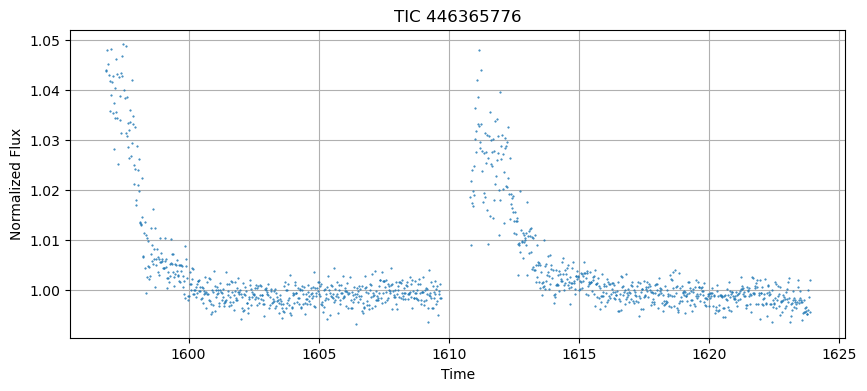


PIPELINE COMPLETE

Initial TICs collected: 8794
Downloaded light curves: 289
Final ML sample: 289

Research outputs generated:
✔ TIC cache
✔ Partial feature cache
✔ Clean feature matrix
✔ PCA projection
✔ KMeans clustering
✔ CSV results table
✔ PCA visualization
✔ Sample light curve plots

Done.


In [5]:
# ============================================================
# FULL RESEARCH-STYLE TESS VARIABLE STAR ML PIPELINE
# FULLY FIXED + ROBUST VERSION
# ============================================================
#
# WHAT THIS DOES:
#
# 1. Finds REAL TESS-observed stars
# 2. Builds valid TIC dataset using SkyCoord
# 3. Downloads clean TESS light curves
# 4. Extracts variability features
# 5. Cleans + scales features
# 6. Runs PCA + KMeans clustering
# 7. Produces plots + CSV outputs
#
# ============================================================
# INSTALLS (RUN ONCE IF NEEDED)
# ============================================================
#
# pip install lightkurve astropy scikit-learn tqdm matplotlib pandas numpy
#
# ============================================================

# ============================================================
# IMPORTS
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import os
import time

os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightkurve as lk

from tqdm import tqdm

from astropy.timeseries import LombScargle
from astropy.coordinates import SkyCoord
import astropy.units as u

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# ============================================================
# SETTINGS
# ============================================================

N_REGIONS = 25

MAX_TICS_TO_PROCESS = 300

MIN_POINTS = 100

N_CLUSTERS = 4

RANDOM_SEED = 42

TIC_CACHE_FILE = "tic_cache.csv"

FEATURE_CACHE_FILE = "partial_features.csv"

FINAL_RESULTS_FILE = "tess_variable_star_clusters.csv"

np.random.seed(RANDOM_SEED)

# ============================================================
# OPTIONAL: DELETE BAD OLD CACHE
# ============================================================

if os.path.exists(TIC_CACHE_FILE):

    existing = pd.read_csv(TIC_CACHE_FILE)

    if len(existing) == 0:

        print("\nRemoving empty/broken TIC cache...")

        os.remove(TIC_CACHE_FILE)

# ============================================================
# STEP 1 — BUILD REAL TESS TARGET SAMPLE
# ============================================================

print("\n===================================================")
print("[STEP 1] BUILDING REAL TESS TARGET SAMPLE")
print("===================================================")

def get_tics_from_region(ra, dec, radius=0.2):

    try:

        # ----------------------------------------------------
        # PROPER ASTRONOMICAL COORDINATES
        # ----------------------------------------------------

        coord = SkyCoord(
            ra=ra * u.deg,
            dec=dec * u.deg,
            frame="icrs"
        )

        # ----------------------------------------------------
        # SEARCH TESS LIGHT CURVES
        # ----------------------------------------------------

        search = lk.search_lightcurve(
            coord,
            radius=radius * u.deg,
            mission="TESS"
        )

        if len(search) == 0:
            return []

        tics = []

        # ----------------------------------------------------
        # EXTRACT TIC IDS
        # ----------------------------------------------------

        for r in search:

            try:

                target = str(r.target_name)

                # extract numeric characters only
                digits = "".join(
                    c for c in target
                    if c.isdigit()
                )

                if digits != "":

                    tic = int(digits)

                    tics.append(tic)

            except Exception as e:

                print("\nTarget extraction failed:")
                print(r.target_name)
                print(e)

        return tics

    except Exception as e:

        print("\nRegion query failed:")
        print(f"RA={ra}, DEC={dec}")
        print(e)

        return []

# ============================================================
# LOAD TIC CACHE OR GENERATE NEW SAMPLE
# ============================================================

if os.path.exists(TIC_CACHE_FILE):

    print("\nLoading TIC cache...")

    all_tics = pd.read_csv(TIC_CACHE_FILE)["TIC"].tolist()

    print(f"Loaded {len(all_tics)} TICs.")

else:

    print("\nGenerating new TIC sample...")

    all_tics = []

    for i in tqdm(range(N_REGIONS)):

        # random sky position
        ra = np.random.uniform(0, 360)

        dec = np.random.uniform(-75, 75)

        tics = get_tics_from_region(ra, dec)

        all_tics.extend(tics)

        # avoid hammering servers
        time.sleep(0.5)

    # remove duplicates
    all_tics = list(set(all_tics))

    # save cache
    pd.DataFrame({
        "TIC": all_tics
    }).to_csv(
        TIC_CACHE_FILE,
        index=False
    )

    print(f"\nSaved TIC cache: {TIC_CACHE_FILE}")

print(f"\nTotal TICs collected: {len(all_tics)}")

if len(all_tics) == 0:

    raise ValueError(
        "\nNo TICs collected.\n"
        "Possible causes:\n"
        "- internet issue\n"
        "- MAST outage\n"
        "- Lightkurve API issue\n"
        "- coordinate query failure"
    )

# ============================================================
# STEP 2 — DOWNLOAD LIGHT CURVES
# ============================================================

print("\n===================================================")
print("[STEP 2] DOWNLOADING LIGHT CURVES")
print("===================================================")

def get_lc_safe(tic):

    for attempt in range(3):

        try:

            search = lk.search_lightcurve(
                f"TIC {tic}",
                mission="TESS"
            )

            if len(search) == 0:
                return None

            # ------------------------------------------------
            # DOWNLOAD FIRST AVAILABLE LIGHT CURVE
            # ------------------------------------------------

            lc = search[0].download()

            if lc is None:
                return None

            # ------------------------------------------------
            # CLEANING
            # ------------------------------------------------

            lc = lc.remove_nans()

            lc = lc.remove_outliers(sigma=5)

            if len(lc.flux) < MIN_POINTS:
                return None

            lc = lc.normalize()

            return lc

        except Exception as e:

            print(f"\nDownload failed for TIC {tic}")
            print(f"Attempt {attempt+1}/3")
            print(e)

            time.sleep(3)

    return None

lightcurves = []

valid_tics = []

for tic in tqdm(all_tics[:MAX_TICS_TO_PROCESS]):

    lc = get_lc_safe(tic)

    if lc is not None:

        lightcurves.append(lc)

        valid_tics.append(tic)

print(f"\nValid light curves downloaded: {len(lightcurves)}")

if len(lightcurves) == 0:

    raise ValueError(
        "\nNo valid light curves downloaded."
    )

# ============================================================
# STEP 3 — FEATURE EXTRACTION
# ============================================================

print("\n===================================================")
print("[STEP 3] EXTRACTING FEATURES")
print("===================================================")

FEATURE_COLUMNS = [

    "MeanFlux",
    "StdFlux",
    "Amplitude",
    "RMS",
    "MAD",
    "BestPeriod",
    "LSPower",
    "Slope",
    "VarIndex"

]

# ============================================================
# LOAD EXISTING FEATURE CACHE
# ============================================================

if os.path.exists(FEATURE_CACHE_FILE):

    existing = pd.read_csv(FEATURE_CACHE_FILE)

    completed_tics = set(existing["TIC"])

    results_rows = existing.to_dict("records")

    print(f"\nLoaded {len(completed_tics)} existing features.")

else:

    completed_tics = set()

    results_rows = []

# ============================================================
# FEATURE EXTRACTION FUNCTION
# ============================================================

def extract_features(lc):

    try:

        time_vals = lc.time.value

        flux_vals = lc.flux.value

        # ----------------------------------------------------
        # CLEAN FINITE VALUES
        # ----------------------------------------------------

        mask = (
            np.isfinite(time_vals)
            &
            np.isfinite(flux_vals)
        )

        time_vals = time_vals[mask]

        flux_vals = flux_vals[mask]

        if len(flux_vals) < MIN_POINTS:
            return None

        # ----------------------------------------------------
        # BASIC STATISTICS
        # ----------------------------------------------------

        mean_flux = np.mean(flux_vals)

        std_flux = np.std(flux_vals)

        amplitude = (
            np.percentile(flux_vals, 95)
            -
            np.percentile(flux_vals, 5)
        )

        rms = np.sqrt(
            np.mean(
                (flux_vals - mean_flux) ** 2
            )
        )

        median_flux = np.median(flux_vals)

        mad = np.median(
            np.abs(flux_vals - median_flux)
        )

        # ----------------------------------------------------
        # LOMB-SCARGLE PERIOD SEARCH
        # ----------------------------------------------------

        frequency, power = LombScargle(
            time_vals,
            flux_vals
        ).autopower(
            minimum_frequency=0.01,
            maximum_frequency=5
        )

        best_frequency = frequency[np.argmax(power)]

        best_period = 1 / best_frequency

        best_power = np.max(power)

        # ----------------------------------------------------
        # VARIABILITY METRICS
        # ----------------------------------------------------

        slope = np.mean(np.diff(flux_vals))

        variability_index = amplitude / std_flux

        return [

            mean_flux,
            std_flux,
            amplitude,
            rms,
            mad,
            best_period,
            best_power,
            slope,
            variability_index

        ]

    except Exception as e:

        print("\nFeature extraction failed:")
        print(e)

        return None

# ============================================================
# RUN FEATURE EXTRACTION
# ============================================================

for tic, lc in tqdm(
    zip(valid_tics, lightcurves),
    total=len(lightcurves)
):

    if tic in completed_tics:
        continue

    feat = extract_features(lc)

    if feat is not None:

        row = {

            "TIC": tic,

            "MeanFlux": feat[0],
            "StdFlux": feat[1],
            "Amplitude": feat[2],
            "RMS": feat[3],
            "MAD": feat[4],
            "BestPeriod": feat[5],
            "LSPower": feat[6],
            "Slope": feat[7],
            "VarIndex": feat[8]

        }

        results_rows.append(row)

        # ----------------------------------------------------
        # CONTINUOUS SAVE
        # ----------------------------------------------------

        pd.DataFrame(results_rows).to_csv(
            FEATURE_CACHE_FILE,
            index=False
        )

results = pd.DataFrame(results_rows)

print(f"\nFeature rows extracted: {len(results)}")

if len(results) == 0:

    raise ValueError(
        "\nNo valid features extracted."
    )

# ============================================================
# STEP 4 — CLEAN FEATURE MATRIX
# ============================================================

print("\n===================================================")
print("[STEP 4] CLEANING FEATURE MATRIX")
print("===================================================")

# --------------------------------------------------------
# FORCE PURE NUMERIC TYPES (CRITICAL FIX)
# --------------------------------------------------------

for col in FEATURE_COLUMNS:
    results[col] = pd.to_numeric(results[col], errors="coerce")

# --------------------------------------------------------
# BUILD SAFE NUMPY ARRAY
# --------------------------------------------------------

X = results[FEATURE_COLUMNS].to_numpy(dtype=np.float64)

# --------------------------------------------------------
# REMOVE INVALID ROWS
# --------------------------------------------------------

mask = np.isfinite(X).all(axis=1)

results = results.loc[mask].reset_index(drop=True)
X = X[mask]

print(f"\nRemaining stars after cleaning: {len(X)}")

if len(X) == 0:
    raise ValueError("Feature matrix empty after cleaning.")

# ============================================================
# STEP 5 — FEATURE SCALING
# ============================================================

print("\n===================================================")
print("[STEP 5] FEATURE SCALING")
print("===================================================")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaling complete.")

# ============================================================
# STEP 6 — PCA REDUCTION
# ============================================================

print("\n===================================================")
print("[STEP 6] PCA REDUCTION")
print("===================================================")

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nExplained variance ratio:")

print(pca.explained_variance_ratio_)

print(
    f"\nTotal explained variance: "
    f"{np.sum(pca.explained_variance_ratio_):.3f}"
)

# ============================================================
# STEP 7 — KMEANS CLUSTERING
# ============================================================

print("\n===================================================")
print("[STEP 7] KMEANS CLUSTERING")
print("===================================================")

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=RANDOM_SEED,
    n_init=10
)

labels = kmeans.fit_predict(X_pca)

results["Cluster"] = labels

results["PC1"] = X_pca[:, 0]

results["PC2"] = X_pca[:, 1]

print("\nClustering complete.")

# ============================================================
# STEP 8 — SAVE FINAL RESULTS
# ============================================================

print("\n===================================================")
print("[STEP 8] SAVING RESULTS")
print("===================================================")

results.to_csv(
    FINAL_RESULTS_FILE,
    index=False
)

print(f"\nSaved: {FINAL_RESULTS_FILE}")

print("\nResults preview:\n")

print(results.head())

# ============================================================
# STEP 9 — PCA VISUALIZATION
# ============================================================

print("\n===================================================")
print("[STEP 9] PCA VISUALIZATION")
print("===================================================")

plt.figure(figsize=(10, 7))

scatter = plt.scatter(

    results["PC1"],
    results["PC2"],

    c=results["Cluster"],

    s=40

)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("TESS Variable Star Clustering")

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.grid(True)

plt.show()

# ============================================================
# STEP 10 — SAMPLE LIGHT CURVES
# ============================================================

print("\n===================================================")
print("[STEP 10] SAMPLE LIGHT CURVES")
print("===================================================")

N_SAMPLES = min(3, len(lightcurves))

for i in range(N_SAMPLES):

    lc = lightcurves[i]

    plt.figure(figsize=(10, 4))

    plt.plot(

        lc.time.value,
        lc.flux.value,

        ".",

        markersize=1

    )

    plt.xlabel("Time")

    plt.ylabel("Normalized Flux")

    plt.title(f"TIC {valid_tics[i]}")

    plt.grid(True)

    plt.show()

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n===================================================")
print("PIPELINE COMPLETE")
print("===================================================")

print(f"\nInitial TICs collected: {len(all_tics)}")

print(f"Downloaded light curves: {len(lightcurves)}")

print(f"Final ML sample: {len(results)}")

print("\nResearch outputs generated:")

print("✔ TIC cache")
print("✔ Partial feature cache")
print("✔ Clean feature matrix")
print("✔ PCA projection")
print("✔ KMeans clustering")
print("✔ CSV results table")
print("✔ PCA visualization")
print("✔ Sample light curve plots")

print("\nDone.")